In [1]:
%matplotlib widget
from ipywidgets import *
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import sympy as sym
from sympy import symbols, Matrix, latex, expand, I, simplify
from IPython.display import display, Math

plt.style.use('dark_background')

fontsize = 14
mpl.rcParams.update({
        "text.usetex": False,
        "figure.figsize": (9, 6),
        "figure.autolayout": True,
        "font.family": "serif",
        "font.serif": "georgia",
        # 'mathtext.fontset': 'cm',
        "lines.linewidth": 1.5,
        "font.size": fontsize,
        "xtick.labelsize": fontsize,
        "ytick.labelsize": fontsize,
        "legend.fancybox": True,
        "legend.fontsize": fontsize,
        "legend.framealpha": 0.7,
        "legend.handletextpad": 0.5,
        "legend.labelspacing": 0.2,
        "legend.loc": "best",
        "axes.edgecolor": "#b0b0b0",
        "grid.color": "#707070",  # grid color"
        "xtick.color": "#b0b0b0",
        "ytick.color": "#b0b0b0",
        "savefig.dpi": 80,
        "pdf.compression": 9,
})

# **Question 1.1 Solution:**

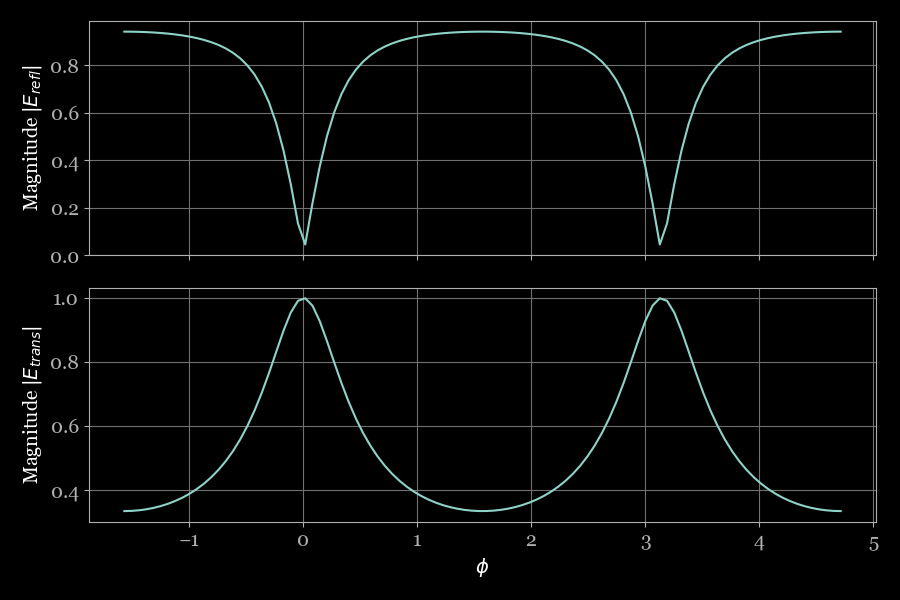

In [2]:
r1, r2 = 1/np.sqrt(2), 1/np.sqrt(2)
t1, t2 = 1/np.sqrt(2), 1/np.sqrt(2)
phi = np.linspace(-0.5*np.pi,(3/2)*np.pi, 100)
Erefl = (r1-r2*np.exp(-2*1j*phi))/(1-r1*r2*np.exp(-2*1j*phi))
Etrans = (t1*t2*np.exp(-2*1j*phi))/(1-r1*r2*np.exp(-2*1j*phi))

fig, (ax1, ax2) = plt.subplots(2, sharex=True)

ax1.plot(phi, np.abs(Erefl))
ax2.plot(phi, np.abs(Etrans))

ax1.grid()
ax2.grid()

ax1.set_ylabel(r"Magnitude $|E_{refl}|$")
ax2.set_ylabel(r"Magnitude $|E_{trans}|$")
ax2.set_xlabel(r"$\phi$")

plt.show()

Based off the plots above you can see that the resonance points for $E_{refl} \& E_{trans}$ are different. For $E_{refl}$ the resonance point is just about zero. For $E_{trans}$ the resonance point is just about one. 

# **Question 1.2 Solution:**

$$ E_{trans} =  \dfrac{t_1 t_2 e^{(-2 i \phi)}}{1 - r_1 r_2 e^{(-2 i \phi)}}$$
Applying the length modulation $ \Delta x \cos(\omega t) $
$$ E_{trans}(t) =  (1 + i k \Delta x e^{i \omega t} + i k \Delta x e^{-i \omega t})\dfrac{t_1 t_2 e^{(-2 i \phi)}}{1 - r_1 r_2 e^{(-2 i \phi)}}$$

# **Question 1.3 Solution:**

In [3]:
r1, r2, t1, t2, phi, k, Delta_x, omega, t, x = symbols('r1 r2 t1 t2 phi k Delta_x omega t x')
Etrans = (1+(I*k*Delta_x*sym.exp(I*omega*t))+(I*k*Delta_x*sym.exp(-I*omega*t)))*(t1*t2*sym.exp(-2*I*phi))/(1-r1*r2*sym.exp(-2*I*phi))
Ptrans = ((1+(I*k*Delta_x*sym.exp(I*omega*t))+(I*k*Delta_x*sym.exp(-I*omega*t)))*(t1*t2*sym.exp(-2*I*phi))/(1-r1*r2*sym.exp(-2*I*phi)))*((1+(I*k*Delta_x*sym.exp(-I*omega*t))+(I*k*Delta_x*sym.exp(I*omega*t)))*(t1*t2*sym.exp(2*I*phi))/(1-r1*r2*sym.exp(2*I*phi)))
Ptrans = expand(Ptrans)
Ptrans = Ptrans.subs(Delta_x**2, 0)
Ptrans

2*I*Delta_x*k*t1**2*t2**2/(r1**2*r2**2*exp(I*omega*t) - r1*r2*exp(2*I*phi)*exp(I*omega*t) - r1*r2*exp(-2*I*phi)*exp(I*omega*t) + exp(I*omega*t)) + 2*I*Delta_x*k*t1**2*t2**2*exp(I*omega*t)/(r1**2*r2**2 - r1*r2*exp(2*I*phi) - r1*r2*exp(-2*I*phi) + 1) + t1**2*t2**2/(r1**2*r2**2 - r1*r2*exp(2*I*phi) - r1*r2*exp(-2*I*phi) + 1)

# **Question 1.4 Solution:**

In [4]:
PtransI = (1/(2*sym.pi))*sym.integrate(Ptrans*sym.cos(x), (x, 0, 2*sym.pi))
PtransQ = (1/(2*sym.pi))*sym.integrate(Ptrans*sym.sin(x), (x, 0, 2*sym.pi))
Ptrans_w = PtransI + I*PtransQ
Ptrans_w

Piecewise((0, Ne(4*r1**4*r2**4*exp(4*I*phi)*exp(2*I*omega*t) - 8*r1**3*r2**3*exp(6*I*phi)*exp(2*I*omega*t) - 8*r1**3*r2**3*exp(2*I*phi)*exp(2*I*omega*t) + 4*r1**2*r2**2*exp(8*I*phi)*exp(2*I*omega*t) + 16*r1**2*r2**2*exp(4*I*phi)*exp(2*I*omega*t) + 4*r1**2*r2**2*exp(2*I*omega*t) - 8*r1*r2*exp(6*I*phi)*exp(2*I*omega*t) - 8*r1*r2*exp(2*I*phi)*exp(2*I*omega*t) + 4*exp(4*I*phi)*exp(2*I*omega*t), 0)), (2*pi*(4*I*Delta_x*k*t1**2*t2**2*exp(2*I*phi)*exp(2*I*omega*t) + 4*I*Delta_x*k*t1**2*t2**2*exp(2*I*phi) + 2*t1**2*t2**2*exp(2*I*phi)*exp(I*omega*t))/(2*r1**2*r2**2*exp(2*I*phi)*exp(I*omega*t) - 2*r1*r2*exp(4*I*phi)*exp(I*omega*t) - 2*r1*r2*exp(I*omega*t) + 2*exp(2*I*phi)*exp(I*omega*t)), True))/(2*pi)

$$ P_{trans}(w) = \dfrac{4i\Delta x k T_1 T_2 e^{2i(\phi+\omega t)} + 4i\Delta x k T_1 T_2 e^{2i\phi} + 2T_1T_2e^{i(2\phi+\omega t)}}{2R_1R_2e^{i(2\phi+\omega t)} - 2r_1r_2e^{i(4\phi+\omega t)} - 2r_1r_2e^{i\omega t} + 2e^{i(2\phi+\omega t)}} $$

# **Question 1.5 Solution:**

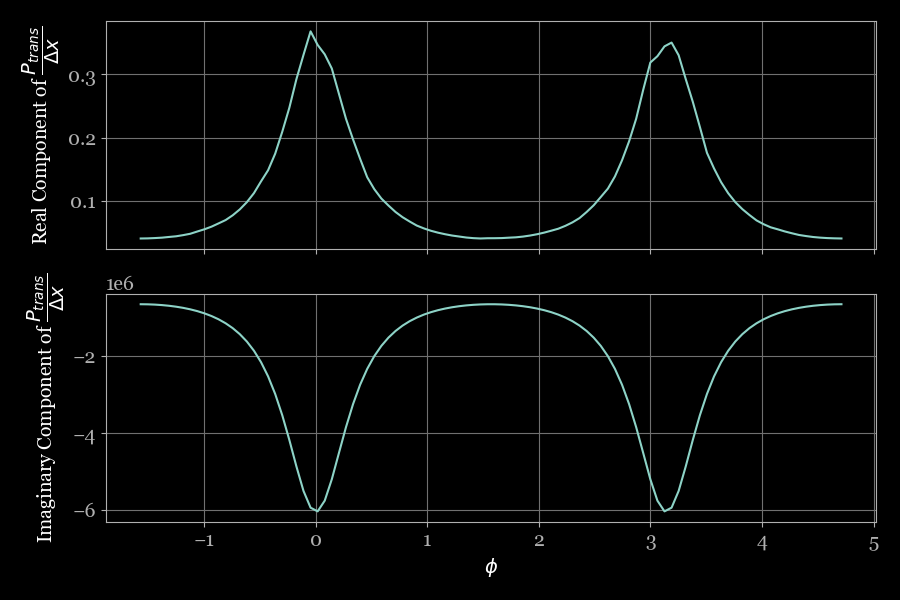

In [5]:
r1, r2 = 1/np.sqrt(2), 1/np.sqrt(2)
T1, T2 = 0.3, 0.3
omega = 200*np.pi
L = 1
l = 1064*(10**-9)
T = 2*np.pi/omega
v = l/T
t = L/v
k = 2*np.pi/l

phi = np.linspace(-0.5*np.pi,(3/2)*np.pi, 100)
Ptrans = (4*1j*k*T1*T2*np.exp(2*1j*(phi+omega*t)) + 4*1j*k*T1*T2*np.exp(2*1j*phi) + 2*T1*T2*np.exp(2*1j*phi+1j*omega*t))/(2*(r1**2)*(r2**2)*np.exp(1j*(2*phi+omega*t)) - 2*r1*r2*np.exp(1j*(4*phi+omega*t)) - 2*r1*r2*np.exp(1j*omega*t) + 2*np.exp(1j*(2*phi+omega*t)))

fig, (ax1, ax2) = plt.subplots(2, sharex=True)

ax1.plot(phi, np.real(Ptrans))
ax2.plot(phi, np.imag(Ptrans))

ax1.grid()
ax2.grid()

ax1.set_ylabel(r"Real Component of $\dfrac{P_{trans}}{\Delta x}$")
ax2.set_ylabel(r"Imaginary Component of $\dfrac{P_{trans}}{\Delta x}$")
ax2.set_xlabel(r"$\phi$")

plt.show()

# **Question 1.6 Solution:**

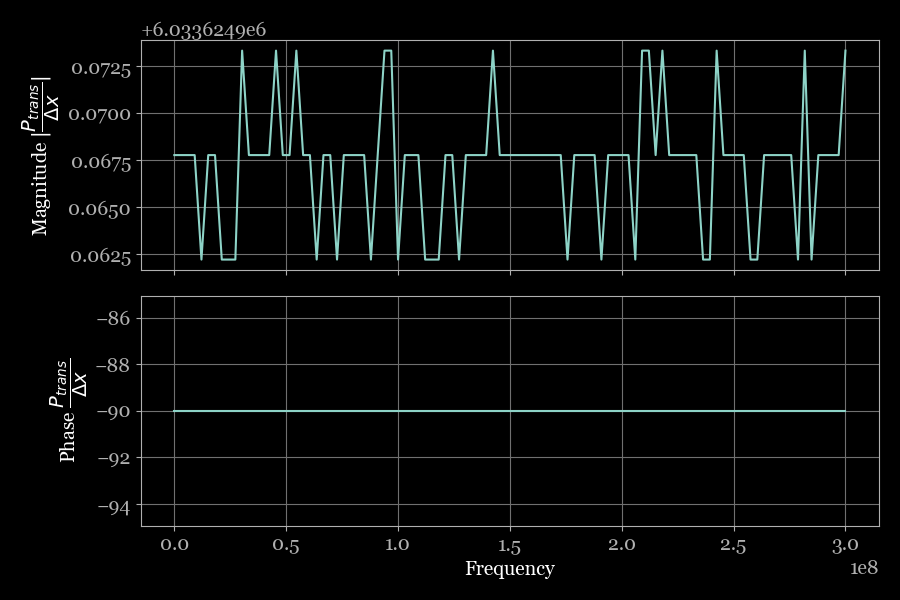

In [6]:
r1, r2 = 1/np.sqrt(2), 1/np.sqrt(2)
T1, T2 = 0.3, 0.3
f = np.linspace(3*10**3,3*10**8, 100)
omega = f*2*np.pi
L = 1
l = 1064*(10**-9)
T = 2*np.pi/omega
v = l/T
t = L/v
k = 2*np.pi/l
phi = 1*np.pi/180

Ptrans = (4*1j*k*T1*T2*np.exp(2*1j*(phi+omega*t)) + 4*1j*k*T1*T2*np.exp(2*1j*phi) + 2*T1*T2*np.exp(2*1j*phi+1j*omega*t))/(2*(r1**2)*(r2**2)*np.exp(1j*(2*phi+omega*t)) - 2*r1*r2*np.exp(1j*(4*phi+omega*t)) - 2*r1*r2*np.exp(1j*omega*t) + 2*np.exp(1j*(2*phi+omega*t)))

fig, (ax1, ax2) = plt.subplots(2, sharex=True)

ax1.plot(f, np.abs(Ptrans))
ax2.plot(f, np.angle(Ptrans, deg=True))

ax1.grid()
ax2.grid()

ax1.set_ylabel(r"Magnitude $|\dfrac{P_{trans}}{\Delta x}|$")
ax2.set_ylabel(r"Phase $\dfrac{P_{trans}}{\Delta x}$")
ax2.set_xlabel(r"Frequency")

plt.show()

# **Question 2.1 Solution:**

In [7]:
r_bs, t_bs, r_y, r_x, phi_x, phi_y, Gamma, Omega, t, phi_d  = symbols('r_bs t_bs r_y r_x phi_x phi_y Gamma Omega t phi_d')
Eas_in = (r_bs*t_bs*r_y*sym.exp(-2*I*phi_y) - r_bs*t_bs*r_x*sym.exp(-2*I*phi_x))*(1+I*(Gamma/2)*sym.exp(I*Omega*t)+I*(Gamma/2)*sym.exp(-I*Omega*t))
expand(Eas_in)

-I*Gamma*r_bs*r_x*t_bs*exp(-2*I*phi_x)*exp(I*Omega*t)/2 - I*Gamma*r_bs*r_x*t_bs*exp(-2*I*phi_x)*exp(-I*Omega*t)/2 + I*Gamma*r_bs*r_y*t_bs*exp(-2*I*phi_y)*exp(I*Omega*t)/2 + I*Gamma*r_bs*r_y*t_bs*exp(-2*I*phi_y)*exp(-I*Omega*t)/2 - r_bs*r_x*t_bs*exp(-2*I*phi_x) + r_bs*r_y*t_bs*exp(-2*I*phi_y)

# **Question 2.2 Solution:**

In [8]:
Pas = ((r_bs*t_bs*r_y*sym.exp(-2*I*phi_y) - r_bs*t_bs*r_x*sym.exp(-2*I*phi_x))*(1+I*(Gamma/2)*sym.exp(I*Omega*t)+I*(Gamma/2)*sym.exp(-I*Omega*t)))*((r_bs*t_bs*r_y*sym.exp(2*I*phi_y) - r_bs*t_bs*r_x*sym.exp(2*I*phi_x))*(1+I*(Gamma/2)*sym.exp(-I*Omega*t)+I*(Gamma/2)*sym.exp(I*Omega*t))
)
Pas = expand(Pas)
Pas = Pas.subs(Gamma**2, 0)
Pas

I*Gamma*r_bs**2*r_x**2*t_bs**2*exp(I*Omega*t) + I*Gamma*r_bs**2*r_x**2*t_bs**2*exp(-I*Omega*t) - I*Gamma*r_bs**2*r_x*r_y*t_bs**2*exp(2*I*phi_x)*exp(-2*I*phi_y)*exp(I*Omega*t) - I*Gamma*r_bs**2*r_x*r_y*t_bs**2*exp(2*I*phi_x)*exp(-2*I*phi_y)*exp(-I*Omega*t) - I*Gamma*r_bs**2*r_x*r_y*t_bs**2*exp(-2*I*phi_x)*exp(2*I*phi_y)*exp(I*Omega*t) - I*Gamma*r_bs**2*r_x*r_y*t_bs**2*exp(-2*I*phi_x)*exp(2*I*phi_y)*exp(-I*Omega*t) + I*Gamma*r_bs**2*r_y**2*t_bs**2*exp(I*Omega*t) + I*Gamma*r_bs**2*r_y**2*t_bs**2*exp(-I*Omega*t) + r_bs**2*r_x**2*t_bs**2 - r_bs**2*r_x*r_y*t_bs**2*exp(2*I*phi_x)*exp(-2*I*phi_y) - r_bs**2*r_x*r_y*t_bs**2*exp(-2*I*phi_x)*exp(2*I*phi_y) + r_bs**2*r_y**2*t_bs**2

# **Question 2.3 Solution:**

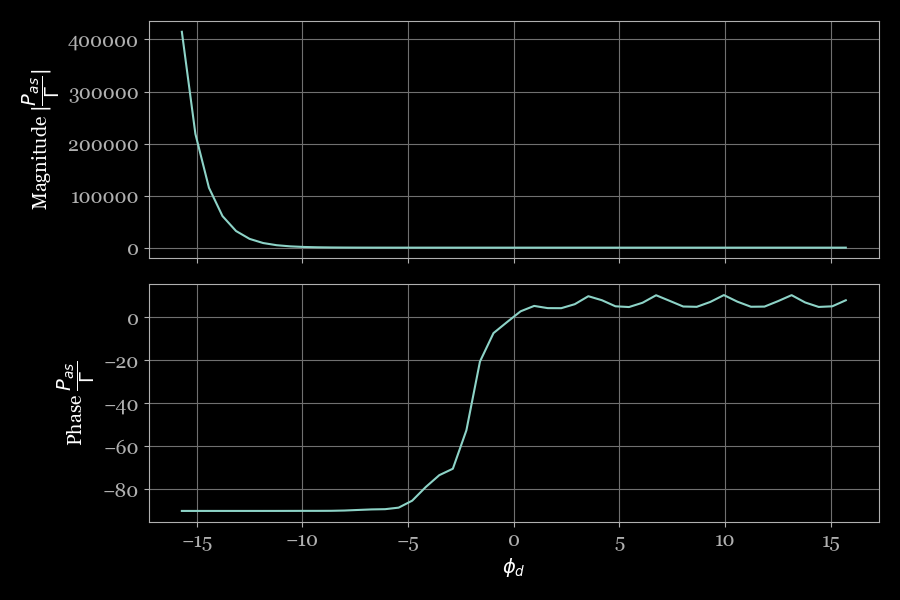

In [9]:
rx, ry = 1, 1
rbs, tbs = 1/np.sqrt(2), 1/np.sqrt(2)
Omega = 2*np.pi*(10*10**6)
c = 3*10**8
Lx, Ly = 5, 5
phid = np.linspace(-5*np.pi, 5*np.pi)
t = Lx/c

Pas = 1j*(rbs**2)*(rx**2)*(tbs**2)*(1/2)*np.cos(Omega*t) - (1/2)*(rbs**2)*(rx)*(ry)*(tbs**2)*np.sin(2*phid + Omega*t) - 1j*(rbs**2)*(rx)*(ry)*(tbs**2)*np.exp(-phid)*(1/2)*np.cos(Omega*t) + (1/2)*(rbs**2)*(ry**2)*(tbs**2)*np.cos(Omega*t) - (1/2)*(rbs**2)*(rx)*(ry)*(tbs**2)*np.sin(2*phid) + (rbs**2)*(tbs**2)*((rx**2) + (ry**2))

fig, (ax1, ax2) = plt.subplots(2, sharex=True)

ax1.plot(phid, np.abs(Pas))
ax2.plot(phid, np.angle(Pas, deg=True))

ax1.grid()
ax2.grid()

ax1.set_ylabel(r"Magnitude $|\dfrac{P_{as}}{\Gamma}|$")
ax2.set_ylabel(r"Phase $\dfrac{P_{as}}{\Gamma}$")
ax2.set_xlabel(r"$\phi_d$")

plt.show()

As we increase the value of $\phi_d$ the signal decreases to a value of zero.

# **Question 3.1 Solution:**

The adjacency matrix for this cavity is shown below:
\begin{bmatrix}
0 & 0 & 0 & 0 & 0 & 0 \\

- r_{bs} e^{-i k l_y} & 0 & 0 & 0 & 0 & 0 \\

\frac{
r_{bs} - e^{-2 i k L_y} r_{bs} r_{Iy} r_{Ey} + e^{-2 i k L_y} \left(r_{Iy} - e^{-2 i k L_y} r_{Ey}\right)
}{
1 + e^{-2 i k l_y} r_{bs} r_{Iy}
- e^{-2 i k (l_y + L_y)} r_{bs} r_{Ey}
- e^{-2 i k L_y} r_{Iy} r_{Ey}
}
& - r_{Iy} e^{-i k l_y} & 0 & 0 & 0 & 0 \\

t_{bs} e^{-i k l_x} & 0 & 0 & 0 & 0 & 0 \\

\frac{
r_{bs} - e^{-2 i k L_x} r_{bs} r_{Ix} r_{Ex} + e^{-2 i k L_x} \left(r_{Ix} - e^{-2 i k L_x} r_{Ex}\right)
}{
1 + e^{-2 i k l_x} r_{bs} r_{Ix}
- e^{-2 i k (l_x + L_x)} r_{bs} r_{Ex}
- e^{-2 i k L_x} r_{Ix} r_{Ex}
}
& 0 & 0 & - r_{Ix} e^{-i k l_x} & 0 & 0 \\

0 & 0 & t_{bs} & 0 & r_{bs} & 0
\end{bmatrix}

# **Question 3.2 Solution:**

In [10]:
rbs, rIy, rEy,rIx, rEx, k, Ly, ly,Lx, lx, tbs, Phi_c, Phi_d, r_ITM, r_ETM = symbols('rbs rIy rEy rIx rEx k Ly ly Lx lx tbs Phi_c Phi_d r_ITM r_ETM')
M = Matrix([
    [0,0,0,0,0,0],
    [-rbs*sym.exp(-I*k*ly),0,0,0,0,0],
    [(rbs-sym.exp(-2*I*k*Ly)*rbs*rIy*rEy + sym.exp(-2*I*k*Ly)*(rIy-sym.exp(-2*I*k*Ly)*rEy))/(1+sym.exp(-2*I*k*ly)*rbs*rIy-sym.exp(-2*I*k*(ly+Ly))*rbs*rEy-sym.exp(-2*I*k*Ly)*rIy*rEy),-rIy*sym.exp(-I*k*ly),0,0,0,0],
    [tbs*sym.exp(-I*k*lx),0,0,0,0,0],
    [(rbs-sym.exp(-2*I*k*Lx)*rbs*rIx*rEx + sym.exp(-2*I*k*Lx)*(rIx-sym.exp(-2*I*k*Lx)*rEx))/(1+sym.exp(-2*I*k*lx)*rbs*rIx-sym.exp(-2*I*k*(lx+Lx))*rbs*rEx-sym.exp(-2*I*k*Lx)*rIx*rEx),0,0,-rIx*sym.exp(-I*k*lx),0,0],
    [0,0,tbs,0,rbs,0]
])
Id = Matrix([
    [1,0,0,0,0,0],
    [0,1,0,0,0,0],
    [0,0,1,0,0,0],
    [0,0,0,1,0,0],
    [0,0,0,0,1,0],
    [0,0,0,0,0,1]
])
A = Id-M
Ainv = A.inv(method="LU")
latex_string = sym.latex(Ainv, mat_str="bmatrix")
display(Math(latex_string))

<IPython.core.display.Math object>

From the matrix above you can pull the value of:
$$\dfrac{E_{as}}{E_{in}} = r_{rb}(-r_{ITMx}t_{bs}e^{-2i\phi_x} + \dfrac{-r_{ETMx}r_{ITMx}r_{bs}e^{-2i\Phi_x} + r_{bs} + (-r_{ETMx}e^{-2i\Phi_x}+r_{ITMx})e^{-2\Phi_x}}{-r_{ETMx}r_{ITMx}e^{-2i \Phi_x} - r_{ETMx}r_{bs}e^{-2i(\Phi_x + \phi_x)} + r_{ITMx}r_{bs}e^{-2i\phi_x} + 1} + t_{rb}(-r_{ITMy}t_{bs}e^{-2i\phi_y} + \dfrac{-r_{ETMy}r_{ITMy}r_{bs}e^{-2i\Phi_y} + r_{bs} + (-r_{ETMy}e^{-2i\Phi_y}+r_{ITMy})e^{-2\Phi_y}}{-r_{ETMy}r_{ITMy}e^{-2i \Phi_y} - r_{ETMy}r_{bs}e^{-2i(\Phi_y + \phi_y)} + r_{ITMy}r_{bs}e^{-2i\phi_y} + 1}$$

# **Question 3.3 Solution:**

In [14]:
EasEin = Ainv[5,0]
EasEin = EasEin.subs(rbs, 1/sym.sqrt(2))
EasEin = EasEin.subs(tbs, 1/sym.sqrt(2))
EasEin = EasEin.subs(lx,0)
EasEin = EasEin.subs(ly,0)
EasEin = EasEin.subs(k*Lx,(Phi_c + Phi_d))
EasEin = EasEin.subs(k*Ly,(Phi_c - Phi_d))
EasEin = EasEin.subs(rIy,r_ITM)
EasEin = EasEin.subs(rIx,r_ITM)
EasEin = EasEin.subs(rEy,r_ETM)
EasEin = EasEin.subs(rEx,r_ETM)
EasEin = sym.simplify(EasEin)
EasEin

sqrt(2)*(-(2*r_ETM*r_ITM + sqrt(2)*r_ETM - (sqrt(2)*r_ITM + 2)*exp(2*I*(Phi_c - Phi_d)))*(-2*sqrt(2)*r_ETM*r_ITM*exp(2*I*(Phi_c + Phi_d)) - 4*r_ETM + sqrt(2)*r_ITM*(2*r_ETM*r_ITM + sqrt(2)*r_ETM - (sqrt(2)*r_ITM + 2)*exp(2*I*(Phi_c + Phi_d)))*exp(2*I*(Phi_c + Phi_d)) + 4*r_ITM*exp(2*I*(Phi_c + Phi_d)) + 2*sqrt(2)*exp(4*I*(Phi_c + Phi_d)))*exp(2*I*(Phi_c - Phi_d)) + (2*r_ETM*r_ITM + sqrt(2)*r_ETM - (sqrt(2)*r_ITM + 2)*exp(2*I*(Phi_c + Phi_d)))*(2*sqrt(2)*r_ETM*r_ITM*exp(2*I*(Phi_c - Phi_d)) + 4*r_ETM + sqrt(2)*r_ITM*(2*r_ETM*r_ITM + sqrt(2)*r_ETM - (sqrt(2)*r_ITM + 2)*exp(2*I*(Phi_c - Phi_d)))*exp(2*I*(Phi_c - Phi_d)) - 4*r_ITM*exp(2*I*(Phi_c - Phi_d)) - 2*sqrt(2)*exp(4*I*(Phi_c - Phi_d)))*exp(2*I*(Phi_c + Phi_d)))*exp(-4*I*Phi_c)/(4*(2*r_ETM*r_ITM + sqrt(2)*r_ETM - (sqrt(2)*r_ITM + 2)*exp(2*I*(Phi_c - Phi_d)))*(2*r_ETM*r_ITM + sqrt(2)*r_ETM - (sqrt(2)*r_ITM + 2)*exp(2*I*(Phi_c + Phi_d))))

# **Question 3.4 Solution:**

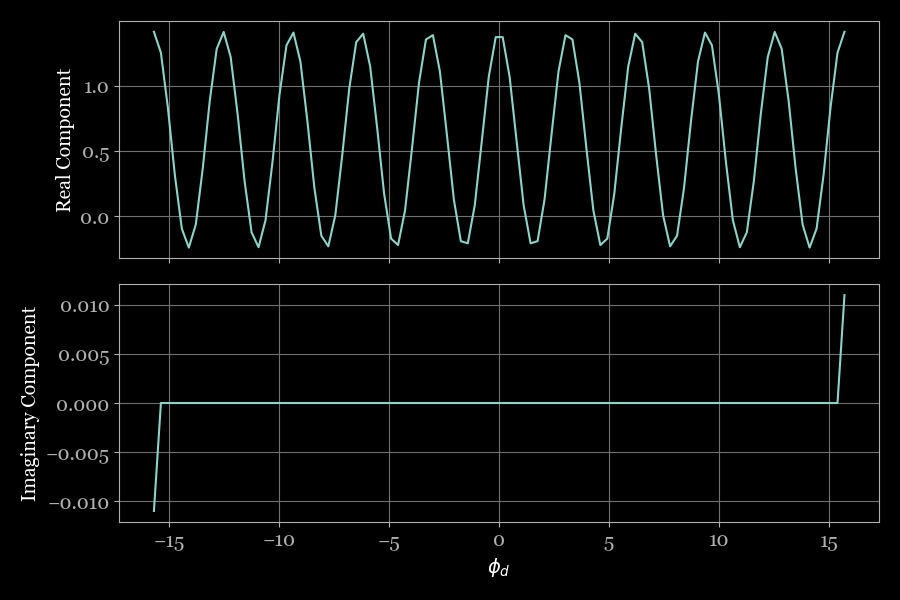

In [17]:
EasEin = EasEin.subs(lx,5)
EasEin = EasEin.subs(ly,5)
EasEin = EasEin.subs(Lx,4000)
EasEin = EasEin.subs(Ly,4000)
EasEin = EasEin.subs(Phi_c,0)
EasEin = EasEin.subs(r_ITM,1)
EasEin = EasEin.subs(r_ETM,1)
phid = np.linspace(-5*np.pi, 5*np.pi, 100)

f = sym.lambdify(Phi_d,EasEin, 'numpy')

E_vals = f(phid)

fig, (ax1, ax2) = plt.subplots(2, sharex=True)

ax1.plot(phid, np.real(E_vals))
ax2.plot(phid, np.imag(E_vals))

ax1.grid()
ax2.grid()

ax1.set_ylabel(r"Real Component")
ax2.set_ylabel(r"Imaginary Component")
ax2.set_xlabel(r"$\phi_d$")

plt.show()

This does not enhance out sensitivity as when we are at the dark port the $E_{as}$ will oscillate which will not tell us if the cavity is at the point of differential displacement. 